In [93]:
import torch
import torchphysics as tp
X = tp.spaces.R1('x')
Y = tp.spaces.R1('y')
U = tp.spaces.R1('u')
V = tp.spaces.R1('v')
C = tp.spaces.R1("c")
URMS = tp.spaces.R1('urms')
VRMS = tp.spaces.R1('vrms')
UV=tp.spaces.R1('uv')
P=tp.spaces.R1('p')

In [94]:
torch.cuda.is_available()

False

In [2]:
import pandas as pd
import numpy as np

In [3]:
class Turbulent_Data(torch.utils.data.Dataset):
    def __init__(self,data_DF,x_list,y_list,Nsamples=30):
        self.x_train=data_DF[x_list].values
        self.y_train=data_DF[y_list].values
        self.N_iter=Nsamples
        self.ids=random.sample(range(len(data_DF)),self.N_iter)
        self.counter=0
    def __len__(self):
        return len(self.y_train)

    def __getitem__(self,idx):
        if idx>self.N_iter:
            raise StopIteration
        #return self.x_train[idx] , self.y_train[idx]
        #print(torch.as_tensor([self.x_train[idx]]).shape)
        if self.counter>(self.N_iter):
            self.counter=0
            self.ids=random.sample(range(len(self.x_train)),self.N_iter)
        idx_local=self.ids[idx]
        #idx_local=idx
        P_xtrain=tp.spaces.Points([self.x_train[idx_local]],X*Y,dtype=torch.float32)
        P_ytrain=tp.spaces.Points([self.y_train[idx_local]],U*V*URMS*VRMS*UV,dtype=torch.float32)
        self.counter+=1
        return P_xtrain,P_ytrain

In [4]:
class Turbulent_Data_3D(torch.utils.data.Dataset):
    def __init__(self,data_DF,x_list,y_list,N_iter=30,N_sample=2000):
        self.x_train=data_DF[x_list].values
        self.y_train=data_DF[y_list].values
        self.N_iter=N_iter
        self.N_sample=N_sample
    def __len__(self):
        return self.N_iter+1

    def __getitem__(self,idx):
        if idx>self.N_iter:
            raise StopIteration
        self.ids=random.sample(range(len(self.x_train)),self.N_sample)
        #return self.x_train[idx] , self.y_train[idx]
        #print(torch.as_tensor([self.x_train[idx]]).shape)
        idx_local=self.ids
        #idx_local=idx
        P_xtrain=tp.spaces.Points([self.x_train[idx_local]],X*Y*C,dtype=torch.float32)
        P_ytrain=tp.spaces.Points([self.y_train[idx_local]],U*V*URMS*VRMS*UV,dtype=torch.float32)
        return P_xtrain,P_ytrain

In [5]:
class Ho_Turbulent_Data(torch.utils.data.Dataset):
    def __init__(self,data_DF,x_list,y_list,horizon_sampler,Nsamples=30):
        self.x_train=data_DF[x_list].values
        self.y_train=data_DF[y_list].values
        self.sampler=horizon_sampler
        self.N_iter=Nsamples
        #self.x_train=torch.tensor(x_train,dtype=torch.float32)
        #self.y_train=torch.tensor(y_train,dtype=torch.float32)
        #self.x_train=tp.spaces.Points(self.x_train,X*Y)
        #self.y_train=tp.spaces.Points(self.y_train,U*V)
    def __len__(self):
        return len(self.y_train)

    def __getitem__(self,idx):
        if idx>self.N_iter:
            raise StopIteration
        x_horizon= self.sampler.sample_points(device="cpu")
        x_horizon,_=x_horizon.track_coord_gradients()
        x_horizon=x_horizon["x"].detach().numpy()
        #print(x_horizon)
        idx_local=np.random.randint(0,len(self.y_train)-1)
        y_new=np.broadcast_to(self.x_train[idx_local],(x_horizon.shape[0],self.x_train[idx_local].shape[0]))
        target_new=np.broadcast_to(self.y_train[idx_local],(x_horizon.shape[0],self.y_train[idx_local].shape[0]))
        X_points = np.concatenate((x_horizon,y_new),axis=1)
        P_xtrain=tp.spaces.Points([X_points],X*Y,dtype=torch.float32)
        P_ytrain=tp.spaces.Points([target_new],U*V*URMS*VRMS*UV,dtype=torch.float32)
        return P_xtrain,P_ytrain

In [6]:
class Rn_Turbulent_Data(torch.utils.data.Dataset):
    def __init__(self,data_DF,x_list,y_list,max_it):
        self.x_train=data_DF[x_list].values
        self.y_train=data_DF[y_list].values
        self.length=min(max_it,len(self.y_train))
        #self.x_train=torch.tensor(x_train,dtype=torch.float32)
        #self.y_train=torch.tensor(y_train,dtype=torch.float32)
        #self.x_train=tp.spaces.Points(self.x_train,X*Y)
        #self.y_train=tp.spaces.Points(self.y_train,U*V)
    def __len__(self):
        return self.length

    def __getitem__(self,idx):
        #return self.x_train[idx] , self.y_train[idx]
        #print(torch.as_tensor([self.x_train[idx]]).shape)
        id_random=random.randint(0,len(self.y_train))
        P_xtrain=tp.spaces.Points([self.x_train[id_random]],X*Y,dtype=torch.float32)
        P_ytrain=tp.spaces.Points([self.y_train[id_random]],U*V*URMS*VRMS*UV,dtype=torch.float32)
        return P_xtrain,P_ytrain

In [7]:
DF_Data=pd.read_csv("Data/Flow_3d_2289_6_C5X144Y91.csv")

In [8]:
DF_Data["V"]=DF_Data["V"]*50

In [9]:
DF_Data["x"].unique()

array([0.   , 0.025, 0.05 , 0.075, 0.1  , 0.125, 0.15 , 0.175, 0.2  ,
       0.225, 0.25 , 0.275, 0.3  , 0.325, 0.35 , 0.375, 0.4  , 0.425,
       0.45 , 0.475, 0.5  , 0.525, 0.55 , 0.575, 0.6  , 0.625, 0.65 ,
       0.675, 0.7  , 0.725, 0.75 , 0.775, 0.8  , 0.825, 0.85 , 0.875,
       0.9  , 0.925, 0.95 , 0.975, 1.   , 1.025, 1.05 , 1.075, 1.1  ,
       1.125, 1.15 , 1.175, 1.2  , 1.225, 1.25 , 1.275, 1.3  , 1.325,
       1.35 , 1.375, 1.4  , 1.425, 1.45 , 1.475, 1.5  , 1.525, 1.55 ,
       1.575, 1.6  , 1.625, 1.65 , 1.675, 1.7  , 1.725, 1.75 , 1.775,
       1.8  , 1.825, 1.85 , 1.875, 1.9  , 1.925, 1.95 , 1.975, 2.   ,
       2.025, 2.05 , 2.075, 2.1  , 2.125, 2.15 , 2.175, 2.2  , 2.225,
       2.25 , 2.275, 2.3  , 2.325, 2.35 , 2.375, 2.4  , 2.425, 2.45 ,
       2.475, 2.5  , 2.525, 2.55 , 2.575, 2.6  , 2.625, 2.65 , 2.675,
       2.7  , 2.725, 2.75 , 2.775, 2.8  , 2.825, 2.85 , 2.875, 2.9  ,
       2.925, 2.95 , 2.975, 3.   , 3.025, 3.05 , 3.075, 3.1  , 3.125,
       3.15 , 3.175,

In [10]:
import random
def Augment_1D_data(DF,Nsampler,L_x):
    DF_out=DF[0:0]
    for _ in range(Nsampler):
        Ny=random.randint(0, len(DF)-1)
        DF_temp=DF.iloc[[Ny]]
        DF_temp["x"]=random.uniform(0,L_x)
        DF_out=pd.concat([DF_out,DF_temp],ignore_index=True)
    return DF_out

        

In [11]:
torch.cuda.device_count()

1

In [12]:
X_interval = tp.domains.Interval(X, 0, 3.6) # <-add the bounds of the Interval (0, 2)
Y_interval = tp.domains.Interval(Y, 0, 2.0)
C_interval = tp.domains.Interval(C,0,288)

Sim_domain = X_interval*Y_interval*C_interval


Y_interval_sub_low=tp.domains.Interval(Y, 0, 0.1)
Sim_domain_sub_low=X_interval*Y_interval_sub_low*C_interval
Y_interval_sub_up=tp.domains.Interval(Y, 2-0.1, 2)
Sim_domain_sub_up=X_interval*Y_interval_sub_up*C_interval



C_sampler = tp.samplers.RandomUniformSampler(C_interval, n_points=100)

In [13]:
#DF_out=Augment_1D_data(DF_Data,8000,2.0)
ho_sampler = tp.samplers.RandomUniformSampler(X_interval, n_points=200)


In [14]:

bound_sampler_low = tp.samplers.RandomUniformSampler(Y_interval.boundary_left*X_interval*C_interval, n_points=250)

bound_sampler_up = tp.samplers.RandomUniformSampler(X_interval*Y_interval.boundary*C_interval, n_points=500)


In [15]:
DF_DIST=pd.read_csv("Data/dist_2289_1Ds.csv",header=None)

In [16]:
x_corr=DF_DIST.iloc[0].to_numpy()
x_corr=torch.tensor(x_corr,requires_grad=False, dtype=torch.float32,device="cuda:0")
dist=DF_DIST.iloc[1:].to_numpy()
dist=torch.tensor(dist, dtype=torch.float32,device="cuda:0")*100

In [17]:
dist.shape

torch.Size([288, 720])

In [18]:
#DF_Data=DF_Data[DF_Data["c"]==0]

In [19]:
flow=DF_Data[DF_Data["c"]==100][["urms"]].to_numpy()

In [20]:
flow_3d=flow.reshape((144,91))

In [21]:
#import matplotlib.pyplot as plt
#plt.imshow(flow_3d)
#x_corr_new=np.linspace(0,144,720)
#plt.plot(dist[100,:],x_corr_new)

In [22]:
def pop_data_in_IBM(DF,dist,x_corr):
    row=0
    DF_new=DF
    while row<=len(DF)-1:
        position_r=sum(x_corr<DF_new["x"][row])-1
        position_l=position_r-1
        height=dist[position_l]+(dist[position_r]-dist[position_l])*(DF_new["x"][row]-x_corr[position_l])/(x_corr[position_r]-x_corr[position_l])
        if (DF_new["y"][row]<=height) or (DF_new["y"][row]>=2-height):
            DF_new.iloc[row][["U","V","urms","vrms","uv"]]=0
            #DF_new.drop(row)
        row+=1
    DF_new.reset_index()
    return DF_new

In [23]:
#DF_processed=pop_data_in_IBM(DF_Data,dist,x_corr)
DF_processed=DF_Data

In [24]:
DF_processed

,x,y,c,U,V,urms,vrms,uv
0,0.000,0.000000,0,2.600656e-15,-1.846436e-16,2.140123e-13,8.047987e-16,-1.577949e-29
1,0.000,0.000609,0,-1.244447e-05,-7.966340e-07,1.448204e-02,1.794938e-04,-8.843710e-07
2,0.000,0.002436,0,4.322685e-06,1.436509e-04,3.735474e-02,2.134866e-03,-2.881185e-05
3,0.000,0.005478,0,6.267886e-06,4.347488e-04,4.808667e-02,7.319462e-03,-1.307674e-04
4,0.000,0.009732,0,1.252351e-05,1.089532e-03,5.116432e-02,1.570136e-02,-3.013878e-04
...,...,...,...,...,...,...,...,...
3773947,3.575,1.990268,287,-8.718233e-05,5.921150e-04,4.687371e-02,1.523083e-02,1.715897e-05
3773948,3.575,1.994522,287,-6.205211e-05,5.554840e-04,4.459196e-02,7.541581e-03,1.730195e-05
3773949,3.575,1.997564,287,-4.603499e-05,2.005988e-04,3.694727e-02,2.517208e-03,4.698951e-06
3773950,3.575,1.999391,287,-1.669597e-05,6.784545e-05,1.769236e-02,3.101213e-04,1.737829e-07


In [25]:
dataset_turbulent=Turbulent_Data_3D(DF_processed,["x","y","c"],["U","V","urms","vrms","uv"],0,30000)

In [26]:
a=iter(dataset_turbulent)


In [27]:
Pa,Pb=next(a)

/usr/local/lib/python3.10/dist-packages/torchphysics/problem/spaces/points.py:31: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:230.)
  self._t = torch.as_tensor(data, **kwargs)


In [28]:
Pa[0]

Points:
{'x': tensor([[2.7750],
        [2.1750],
        [1.4500],
        ...,
        [1.1000],
        [3.2500],
        [1.1000]]), 'y': tensor([[0.5933],
        [1.0698],
        [0.5305],
        ...,
        [0.0297],
        [0.2569],
        [0.0603]]), 'c': tensor([[223.],
        [ 62.],
        [ 17.],
        ...,
        [133.],
        [270.],
        [  7.]])}

In [29]:
Pb[0]

Points:
{'u': tensor([[1.7464e+00],
        [1.9635e+00],
        [1.6737e+00],
        ...,
        [3.7267e-04],
        [1.3245e+00],
        [3.8402e-01]]), 'v': tensor([[-0.0373],
        [-0.1068],
        [-0.0261],
        ...,
        [-0.0693],
        [-0.3139],
        [ 1.8325]]), 'urms': tensor([[1.0572],
        [0.6153],
        [1.1818],
        ...,
        [0.0987],
        [1.4693],
        [1.3892]]), 'vrms': tensor([[0.6896],
        [0.5228],
        [0.7357],
        ...,
        [0.1314],
        [0.8345],
        [0.7090]]), 'uv': tensor([[-0.4464],
        [ 0.0263],
        [-0.6218],
        ...,
        [-0.0063],
        [-0.9868],
        [-1.0932]])}

In [30]:
Pa.as_tensor

tensor([[[2.7750e+00, 5.9326e-01, 2.2300e+02],
         [2.1750e+00, 1.0698e+00, 6.2000e+01],
         [1.4500e+00, 5.3053e-01, 1.7000e+01],
         ...,
         [1.1000e+00, 2.9704e-02, 1.3300e+02],
         [3.2500e+00, 2.5686e-01, 2.7000e+02],
         [1.1000e+00, 6.0307e-02, 7.0000e+00]]])

In [31]:
def IBM_irr_filter_up(x,y,c):
    position_r=torch.tensor([sum(x_corr<x_i)-1 for x_i in x],device="cuda:0")
    #position_r=sum(x_corr<x)
    position_l=position_r-1
    x_new=torch.transpose(x,1,0)[0]
    c_new=torch.transpose(c,1,0)[0]
    c_new = c_new.to(torch.long)
    height=dist[c_new,position_l]/100+(dist[c_new,position_r]/100-dist[c_new,position_l]/100)*(x_new-x_corr[position_l])/(x_corr[position_r]-x_corr[position_l])
    return (y[...,0]>=2-height)   
def IBM_irr_filter_low(x,y,c):
    position_r=torch.tensor([sum(x_corr<x_i)-1 for x_i in x],device="cuda:0")
    #position_r=sum(x_corr<x)
    position_l=position_r-1
    x_new=torch.transpose(x,1,0)[0]
    c_new=torch.transpose(c,1,0)[0]
    c_new = c_new.to(torch.long)
    height=dist[c_new,position_l]/100+(dist[c_new,position_r]/100-dist[c_new,position_l]/100)*(x_new-x_corr[position_l])/(x_corr[position_r]-x_corr[position_l])
    return (y[...,0]<=height)
IBM_sampler_irr_low = tp.samplers.RandomUniformSampler(Sim_domain_sub_low,n_points=1000,filter_fn=IBM_irr_filter_low).make_static(resample_interval=2000)
IBM_sampler_irr_up = tp.samplers.RandomUniformSampler(Sim_domain_sub_up,n_points=1000,filter_fn=IBM_irr_filter_up).make_static(resample_interval=2000)

In [32]:
dist[torch.tensor([2,3,4]),:]

tensor([[4.6190, 4.8046, 4.8913,  ..., 4.5139, 4.4466, 4.5421],
        [4.5187, 4.6302, 4.6446,  ..., 4.5221, 4.4231, 4.4680],
        [4.2911, 4.3568, 4.3290,  ..., 4.3385, 4.2331, 4.2555]],
       device='cuda:0')

In [33]:
torch.tensor([2,3,4])

tensor([2, 3, 4])

In [34]:
dist[torch.tensor([2,3,4]),np.array([0,1,2])]

tensor([4.6190, 4.6302, 4.3290], device='cuda:0')

In [35]:
#Omega_sampler = tp.samplers.RandomUniformSampler(Sim_domain, n_points=500)
#plot           = tp.utils.scatter(X*Y, IBM_sampler_irr_up)

In [36]:
#Omega_sampler = tp.samplers.RandomUniformSampler(Sim_domain, n_points=500)
#plot           = tp.utils.scatter(X*Y, Omega_sampler)

In [37]:
def Inner_filter(x,y,c):
    position_r=torch.tensor([sum(x_corr<x_i)-1 for x_i in x],device="cuda:0")
    #position_r=sum(x_corr<x)
    position_l=position_r-1
    x_new=torch.transpose(x,1,0)[0]
    c_new=torch.transpose(c,1,0)[0]
    c_new = c_new.to(torch.long)
    height=dist[c_new,position_l]/100+(dist[c_new,position_r]/100-dist[c_new,position_l]/100)*(x_new-x_corr[position_l])/(x_corr[position_r]-x_corr[position_l])
    return (y[...,0]>height) &(y[...,0]<2-height)   
inner_sampler = tp.samplers.RandomUniformSampler(Sim_domain, n_points=5000,filter_fn=Inner_filter).make_static(resample_interval=2000)#,filter_fn=Inner_filter)

In [38]:
def self_sin(input):
    return input.sin()
def self_cos(input):
    return input.cos()

In [39]:
import torch.nn as nn
import torch.nn.functional as F
torch.manual_seed(seed=42)
class FCN_model_Fourier_Feature_CNN(nn.Module):
    def __init__(self,input_space,output_space,N_features,sigma_1=1,sigma_2=10):
        super().__init__()
        self.W_1 = torch.tensor(torch.randn(input_space.dim , N_features //2, dtype=torch.float32) * sigma_1, dtype=torch.float32, requires_grad=False)
        self.W_2 = torch.tensor(torch.randn(input_space.dim , N_features //2, dtype=torch.float32) * sigma_2, dtype=torch.float32, requires_grad=False)
        self.register_buffer("selfW1", self.W_1, persistent=False)
        self.register_buffer("selfW2", self.W_2, persistent=False)
        self.output_space=output_space
        self.fc1_l=nn.Linear(in_features=N_features,out_features=150)
        self.fc2_l=nn.Linear(in_features=150,out_features=150)
        self.fc3_l=nn.Linear(in_features=150,out_features=150)
        self.fc4_l=nn.Linear(in_features=150,out_features=150)
        self.fc5_l=nn.Linear(in_features=150,out_features=150)
        self.fc6_l=nn.Linear(in_features=150,out_features=150)
        self.fc7_l=nn.Linear(in_features=150,out_features=150)
        ###
        self.fc1_r=nn.Linear(in_features=N_features,out_features=150)
        self.fc2_r=nn.Linear(in_features=150,out_features=150)
        self.fc3_r=nn.Linear(in_features=150,out_features=150)
        self.fc4_r=nn.Linear(in_features=150,out_features=150)
        self.fc5_r=nn.Linear(in_features=150,out_features=150)
        self.fc6_r=nn.Linear(in_features=150,out_features=150)
        self.fc7_r=nn.Linear(in_features=150,out_features=150)
        



        self.conv1=nn.Conv1d(1,3,3,stride=1,padding=1) #((720-3+2*1)/1)+1 *8=720 *3
        self.act1=nn.LeakyReLU(0.1)
        self.pool1=nn.MaxPool1d(kernel_size=2) # stride=2   (720-2)/2 + 1 *8 = 360 *3
        
        self.conv2=nn.Conv1d(3,6,3,stride=1,padding=1) # ((360-3+2*1)/1)+1 *32 = 360*6
        self.act2=nn.LeakyReLU(0.1)
        self.pool2=nn.MaxPool1d(kernel_size=2) #180*6

        self.conv3=nn.Conv1d(6,9,5,stride=3,padding=1) #((180-5+2*1)/3)+1 *32 = 60*9
        self.act3=nn.LeakyReLU(0.1)
        self.pool3=nn.MaxPool1d(kernel_size=2)# 30*9
        self.flat=nn.Flatten()


        self.fc_combo1=nn.Linear(in_features=int(150*2),out_features=512)
        self.fc_combo2=nn.Linear(in_features=512,out_features=256)
        self.fc_combo3=nn.Linear(in_features=256,out_features=128)
        self.fc_combo4=nn.Linear(in_features=128,out_features=64)
        self.fc_combo5=nn.Linear(in_features=64,out_features=32)


        self.out=nn.Linear(in_features=32,out_features=output_space.dim)
    
    def forward(self,dist_1d,t):###############
        t=t.as_tensor[:,:,0:2]
        t_1=torch.concat((self_sin(torch.matmul(t,self.W_1)),self_cos(torch.matmul(t,self.W_1))),2)
        t_1=F.tanh(self.fc1_l(t_1))
        t_1=F.tanh(self.fc2_l(t_1))
        t_1=F.tanh(self.fc2_l(t_1))
        t_1=F.tanh(self.fc3_l(t_1))
        t_1=F.tanh(self.fc4_l(t_1))
        t_1=F.tanh(self.fc5_l(t_1))
        t_1=F.tanh(self.fc6_l(t_1))
        t_1=F.tanh(self.fc7_l(t_1))
        t_2=torch.concat((self_sin(torch.matmul(t,self.W_2)),self_cos(torch.matmul(t,self.W_2))),2)
        t_2=F.tanh(self.fc1_r(t_2))
        t_2=F.tanh(self.fc2_r(t_2))
        t_2=F.tanh(self.fc2_r(t_2))
        t_2=F.tanh(self.fc3_r(t_2))
        t_2=F.tanh(self.fc4_r(t_2))
        t_2=F.tanh(self.fc5_r(t_2))
        t_2=F.tanh(self.fc6_r(t_2))
        t_2=F.tanh(self.fc7_r(t_2))
        t_figure=self.pool1(self.act1(self.conv1(dist_1d)))
        t_figure=self.pool2(self.act2(self.conv2(t_figure)))
        t_figure=self.pool3(self.act3(self.conv3(t_figure)))
        t=torch.concat((t_1,t_2),2)
        t=F.tanh(self.fc_combo1(t))
        t=F.tanh(self.fc_combo2(t))
        t=F.tanh(self.fc_combo3(t))
        t=F.tanh(self.fc_combo4(t))
        t=F.tanh(self.fc_combo5(t))
        t=self.out(t)
        return tp.problem.spaces.Points(t, self.output_space)
        
model=FCN_model_Fourier_Feature_CNN(input_space=X*Y,output_space=U*V*URMS*VRMS*UV*P,N_features=300)

/tmp/ipykernel_233863/3426150928.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.W_1 = torch.tensor(torch.randn(input_space.dim , N_features //2, dtype=torch.float32) * sigma_1, dtype=torch.float32, requires_grad=False)
/tmp/ipykernel_233863/3426150928.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.W_2 = torch.tensor(torch.randn(input_space.dim , N_features //2, dtype=torch.float32) * sigma_2, dtype=torch.float32, requires_grad=False)


In [120]:
import torch.nn as nn
import torch.nn.functional as F
torch.manual_seed(seed=42)
class FCN_model_Fourier_Feature_CNN(nn.Module):
    def __init__(self,input_space,output_space,N_features,sigma_1=1,sigma_2=10):
        super().__init__()
        self.W_1 = torch.tensor(torch.randn(input_space.dim , N_features //2, dtype=torch.float32,device="cuda:0") * sigma_1, dtype=torch.float32, requires_grad=False)
        self.W_2 = torch.tensor(torch.randn(input_space.dim , N_features //2, dtype=torch.float32,device="cuda:0") * sigma_2, dtype=torch.float32, requires_grad=False)
        self.register_buffer("selfW1", self.W_1, persistent=False)
        self.register_buffer("selfW2", self.W_2, persistent=False)
        self.output_space=output_space
        self.fc1_l=nn.Linear(in_features=N_features,out_features=150,device="cuda:0")
        self.fc2_l=nn.Linear(in_features=150,out_features=150,device="cuda:0")
        self.fc3_l=nn.Linear(in_features=150,out_features=150,device="cuda:0")
        ###
        self.fc1_r=nn.Linear(in_features=N_features,out_features=150,device="cuda:0")
        self.fc2_r=nn.Linear(in_features=150,out_features=150,device="cuda:0")
        self.fc3_r=nn.Linear(in_features=150,out_features=150,device="cuda:0")


        self.conv1=nn.Conv1d(1,3,3,stride=1,padding=1,device="cuda:0") #((720-3+2*1)/1)+1 *8=720 *3
        self.act1=nn.LeakyReLU(0.1)
        #self.pool1=nn.MaxPool1d(kernel_size=2) # stride=2   (720-2)/2 + 1 *8 = 360 *3
        
        self.conv2=nn.Conv1d(3,6,3,stride=1,padding=1,device="cuda:0") # ((720-3+2*1)/1)+1 *32 = 720*6
        self.act2=nn.LeakyReLU(0.1)
        self.pool2=nn.MaxPool1d(kernel_size=2) #360*6

        self.conv3=nn.Conv1d(6,9,5,stride=3,padding=1,device="cuda:0") #((360-5+2*1)/3)+1 *32 = 120*9
        self.act3=nn.LeakyReLU(0.1)
        self.pool3=nn.MaxPool1d(kernel_size=2)# 60*9
        self.conv4=nn.Conv1d(9,12,5,stride=3,padding=1,device="cuda:0") #((60-5+2*1)/3)+1 *32 = 20*9
        self.act4=nn.LeakyReLU(0.1)
        self.pool4=nn.MaxPool1d(kernel_size=2)# 10*12
        self.flat=nn.Flatten()
        
        self.fc_combo1=nn.Linear(in_features=120+300,out_features=512,device="cuda:0")
        self.fc_combo2=nn.Linear(in_features=512,out_features=512,device="cuda:0")
        
        self.out=nn.Linear(in_features=512,out_features=output_space.dim,device="cuda:0")
    def forward(self,dist_1d,t):
        t=t.as_tensor[:,0:2]
        t_1=torch.concat((self_sin(torch.matmul(t,self.W_1)),self_cos(torch.matmul(t,self.W_1))),1)
        t_1=F.tanh(self.fc1_l(t_1))
        t_1=F.tanh(self.fc2_l(t_1))
        t_1=F.tanh(self.fc3_l(t_1))
        t_2=torch.concat((self_sin(torch.matmul(t,self.W_2)),self_cos(torch.matmul(t,self.W_2))),1)
        t_2=F.tanh(self.fc1_r(t_2))
        t_2=F.tanh(self.fc2_r(t_2))
        t_2=F.tanh(self.fc3_r(t_2))
        t_figure=self.act1(self.conv1(dist_1d))
        t_figure=self.pool2(self.act2(self.conv2(t_figure)))
        t_figure=self.pool3(self.act3(self.conv3(t_figure)))
        t_figure=self.pool4(self.act4(self.conv4(t_figure)))
        t=torch.concat((t_1,t_2,self.flat(t_figure)),1)
        t=F.tanh(self.fc_combo1(t))
        t=F.tanh(self.fc_combo2(t))
        t=self.out(t)
        return tp.problem.spaces.Points(t, self.output_space)
        
model=FCN_model_Fourier_Feature_CNN(input_space=X*Y,output_space=U*V*URMS*VRMS*UV*P,N_features=300)

/tmp/ipykernel_233863/2992425414.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.W_1 = torch.tensor(torch.randn(input_space.dim , N_features //2, dtype=torch.float32,device="cuda:0") * sigma_1, dtype=torch.float32, requires_grad=False)
/tmp/ipykernel_233863/2992425414.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.W_2 = torch.tensor(torch.randn(input_space.dim , N_features //2, dtype=torch.float32,device="cuda:0") * sigma_2, dtype=torch.float32, requires_grad=False)


In [121]:

class self_Sin(torch.nn.Module):

  def forward(self, x):
    return torch.sin(x)
#model = tp.models.FCN(input_space=X*Y, output_space=U*V*URMS*VRMS*UV*P, hidden=(100,100,100,100,100,100,100),activations=tp.models.Sinus())#######Activation????

In [122]:
data_cond = tp.conditions.DataCondition_CNN(model, dataset_turbulent, dist_matrix=dist, norm=2.0,root=1.0,weight=1000,use_full_dataset=True,name='Data')

In [123]:
#data_cond = tp.conditions.DataCondition(model, dataset_turbulent, norm=2.0,root=1.0,weight=1000,use_full_dataset=True,name='Data')

In [124]:
def pde_IBM(u,v):
    return torch.abs(u)+torch.abs(v)
pde_cond_IBM_up = tp.conditions.PINNCondition_CNN(model, IBM_sampler_irr_up, pde_IBM, dist_matrix=dist,weight=10,name='IBM_up')
pde_cond_IBM_low = tp.conditions.PINNCondition_CNN(model, IBM_sampler_irr_low, pde_IBM, dist_matrix=dist,weight=10,name='IBM_low')

In [125]:
def pde_IBM_uu(urms,vrms,uv,p):
    return torch.abs(urms)+torch.abs(vrms)+torch.abs(uv)+torch.abs(p)
pde_cond_IBM_up_uu = tp.conditions.PINNCondition_CNN(model, IBM_sampler_irr_up, pde_IBM_uu, dist_matrix=dist,weight=10,name='IBM_up_uu')
pde_cond_IBM_low_uu = tp.conditions.PINNCondition_CNN(model, IBM_sampler_irr_low, pde_IBM_uu, dist_matrix=dist,weight=10,name='IBM_low_uu')

In [126]:
def pde_IBM_p(p):
    return p
pde_cond_IBM_p_up = tp.conditions.PINNCondition_CNN(model, IBM_sampler_irr_up, pde_IBM_p, dist_matrix=dist,weight=100,name='IBM_p_up')
pde_cond_IBM_p_low = tp.conditions.PINNCondition_CNN(model, IBM_sampler_irr_low, pde_IBM_p, dist_matrix=dist,weight=100,name='IBM_p_low')

In [127]:
def pde_mass(u,v,x,y):
    return tp.utils.grad(u,x)+tp.utils.grad(v/50,y)-0.0
pde_cond_mass = tp.conditions.PINNCondition_CNN(model, inner_sampler,pde_mass, dist_matrix=dist, weight=50,name='Conti')

In [128]:
def pde_residual_x(u,v, x, y,urms,vrms,uv,p):
    residual_momentum= u*tp.utils.grad(u,x)+ (v/50)*tp.utils.grad(u,y)+(-tp.utils.laplacian(u, x)-tp.utils.laplacian(u,y))/6000 - 0.02028418+tp.utils.grad(torch.square(urms/6),x)+tp.utils.grad(uv/60,y)+tp.utils.grad(p,x)
    return residual_momentum

pde_cond_x = tp.conditions.PINNCondition_CNN(model, inner_sampler, pde_residual_x, dist_matrix=dist,weight=51,name='Momentum_x')

In [129]:
def pde_residual_y(u,v, x, y,urms,vrms,uv,p):
    residual_momentum= u*tp.utils.grad(v/50,x)+v/50*tp.utils.grad(v/50,y)+(-tp.utils.laplacian(v/50, x)-tp.utils.laplacian(v/50,y))/6000+tp.utils.grad(uv/60,x)+tp.utils.grad(torch.square(vrms/6),y)+tp.utils.grad(p,y)
    return residual_momentum

pde_cond_y = tp.conditions.PINNCondition_CNN(model, inner_sampler, pde_residual_y, dist_matrix=dist,weight=50,name='Momentum_y')

In [130]:
def boundary_residual_x(u, x,y):
    return torch.square(u) - 0.0

boundary_cond_x = tp.conditions.PINNCondition_CNN(model, bound_sampler_up, boundary_residual_x, dist_matrix=dist, weight=1,name='noslip_x')

In [131]:
def boundary_residual_y(v, x,y):
    return torch.square(v) - 0.0

boundary_cond_y = tp.conditions.PINNCondition_CNN(model, bound_sampler_up, boundary_residual_y, dist_matrix=dist, weight=1,name='noslip_y')

In [132]:
def boundary_residual_uu(urms, x,y):
    return torch.square(urms) - 0.0

boundary_cond_uu = tp.conditions.PINNCondition_CNN(model, bound_sampler_up, boundary_residual_uu, dist_matrix=dist, weight=1,name='noslip_x_uu')

In [133]:
def boundary_residual_vv(vrms, x,y):
    return torch.square(vrms) - 0.0

boundary_cond_vv = tp.conditions.PINNCondition_CNN(model, bound_sampler_up, boundary_residual_vv, dist_matrix=dist, weight=1,name='noslip_x_vv')

In [134]:
def boundary_residual_uv(uv, x,y):
    return uv - 0.0

boundary_cond_uv = tp.conditions.PINNCondition_CNN(model, bound_sampler_up, boundary_residual_uv, dist_matrix=dist, weight=1,name='noslip_x_uv')

In [135]:

Periodic_sampler=tp.samplers.RandomUniformSampler(Y_interval*C_interval,n_points=250).make_static(resample_interval=2000)#,filter_fn=Inner_filter)

In [136]:
def periodic_residual_x(u_left,u_right):
    Periodic_condition= u_left - u_right
    return Periodic_condition
periodic_cond_x=tp.conditions.PeriodicCondition_CNN(model,X_interval,periodic_residual_x,dist_matrix=dist,non_periodic_sampler=Periodic_sampler, weight=1,name='periodic_x')

In [137]:
def periodic_residual_y(v_left,v_right):
    Periodic_condition= v_left - v_right
    return Periodic_condition
periodic_cond_y=tp.conditions.PeriodicCondition_CNN(model,X_interval,periodic_residual_y,dist_matrix=dist,non_periodic_sampler=Periodic_sampler, weight=1,name='periodic_y')

In [138]:
def periodic_residual_uu(urms_left,urms_right):
    Periodic_condition= urms_left - urms_right
    return Periodic_condition
periodic_cond_uu=tp.conditions.PeriodicCondition_CNN(model,X_interval,periodic_residual_uu,dist_matrix=dist,non_periodic_sampler=Periodic_sampler, weight=1,name='periodic_uu')

In [139]:
def periodic_residual_vv(vrms_left,vrms_right):
    Periodic_condition= vrms_left - vrms_right
    return Periodic_condition
periodic_cond_vv=tp.conditions.PeriodicCondition_CNN(model,X_interval,periodic_residual_vv,dist_matrix=dist,non_periodic_sampler=Periodic_sampler, weight=1,name='periodic_vv')

In [140]:
def periodic_residual_uv(uv_left,uv_right):
    Periodic_condition= uv_left - uv_right
    return Periodic_condition
periodic_cond_uv=tp.conditions.PeriodicCondition_CNN(model,X_interval,periodic_residual_uv,dist_matrix=dist,non_periodic_sampler=Periodic_sampler, weight=1,name='periodic_uv')

In [141]:
def periodic_residual_p(p_left,p_right):
    Periodic_condition= p_left-p_right
    return Periodic_condition
periodic_cond_p=tp.conditions.PeriodicCondition_CNN(model,X_interval,periodic_residual_p,dist_matrix=dist,non_periodic_sampler=Periodic_sampler, weight=1,name='periodic_p')

In [142]:
bound_sampler_left = tp.samplers.RandomUniformSampler(X_interval.boundary_left*Y_interval*C_interval, n_points=250)
def boundary_residual_p(p, x,y):
    return p

boundary_cond_p = tp.conditions.PINNCondition_CNN(model, bound_sampler_left, boundary_residual_p, dist_matrix=dist, weight=1,name='bound_p')

In [143]:
##Learning rate scheduling To-Do -- launch LR scheduling only after first training phase
optim = tp.OptimizerSetting(torch.optim.Adam, lr=0.001,scheduler_class=torch.optim.lr_scheduler.ReduceLROnPlateau,scheduler_args={"patience":1000,"factor":0.8,"verbose":True,"min_lr":0.000005},monitor_lr="train/loss")
#solver = tp.solver.Solver([pde_cond_IBM,pde_cond_mass,boundary_cond_x, pde_cond_x,periodic_cond_x,boundary_cond_y, pde_cond_y,periodic_cond_y], optimizer_setting=optim)
##loss terms scheduling
list_of_Losses=[pde_cond_IBM_up,#1000
                           pde_cond_IBM_low,
                           pde_cond_IBM_up_uu,#1000
                           pde_cond_IBM_low_uu,
                           #pde_cond_IBM_2,#1000
                            data_cond,
                           boundary_cond_x,#1000
                           boundary_cond_y,
                           boundary_cond_uu,#1000
                           boundary_cond_vv,
                           boundary_cond_uv,
                           boundary_cond_p,
                           periodic_cond_x,#2000
                           periodic_cond_y,
                           periodic_cond_uu,#2000
                           periodic_cond_vv,
                           periodic_cond_uv,
                           periodic_cond_p,
                           pde_cond_x,#5000
                           pde_cond_y,#5000
                           pde_cond_mass]
solver = tp.solver.Solver_CNN(list_of_Losses,#1000
                          optimizer_setting=optim,
                         loss_function_schedule=[
                     {
                        "conditions":list(range(len(list_of_Losses))),
                        "max_iter":20000
                    }
                ],
                          weight_tunning=True,
                          weight_tunning_parameters={
                                    "alfa":0.99,
                                    "E_rho":0.99,
                                    "Temperature":0.1,
                                    "tunning_every_n_steps":100
                          } ## Default weight-tunning settings
                         )

In [144]:
############################################# V*50 , sigma 15 , no bound_p

In [145]:
import pytorch_lightning as pl
from pytorch_lightning import loggers as pl_loggers
torch.set_float32_matmul_precision('medium')
comet_logger = pl_loggers.CSVLogger(save_dir="logs/")
trainer = pl.Trainer(gpus=1,# use one GPU
                     max_steps=30000, # iteration number
                     benchmark=True, # faster if input batch has constant size
                     logger=comet_logger, # for writting into tensorboard
                     log_every_n_steps=100,
                     enable_checkpointing=False) # saving checkpoints ToDo: turn on checkpointing after first training phase
trainer.fit(solver)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name             | Type       | Params
------------------------------------------------
0 | train_conditions | ModuleList | 663 K 
1 | val_conditions   | ModuleList | 0     
------------------------------------------------
663 K     Trainable params
0         Non-trainable params
663 K     Total params
2.652     Total estimated model params size (MB)


Epoch 0:  44%|█████████████████▊                      | 13334/30001 [10:49:16<13:31:34,  2.92s/it, loss=6.01, v_num=127]

/usr/local/lib/python3.10/dist-packages/pytorch_lightning/trainer/call.py:48: UserWarning: Detected KeyboardInterrupt, attempting graceful shutdown...
  rank_zero_warn("Detected KeyboardInterrupt, attempting graceful shutdown...")


In [146]:
import numpy as np

In [147]:
import matplotlib.pyplot as plt

In [148]:
plt.close()

In [149]:
print(model)

FCN_model_Fourier_Feature_CNN(
  (fc1_l): Linear(in_features=300, out_features=150, bias=True)
  (fc2_l): Linear(in_features=150, out_features=150, bias=True)
  (fc3_l): Linear(in_features=150, out_features=150, bias=True)
  (fc1_r): Linear(in_features=300, out_features=150, bias=True)
  (fc2_r): Linear(in_features=150, out_features=150, bias=True)
  (fc3_r): Linear(in_features=150, out_features=150, bias=True)
  (conv1): Conv1d(1, 3, kernel_size=(3,), stride=(1,), padding=(1,))
  (act1): LeakyReLU(negative_slope=0.1)
  (conv2): Conv1d(3, 6, kernel_size=(3,), stride=(1,), padding=(1,))
  (act2): LeakyReLU(negative_slope=0.1)
  (pool2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv1d(6, 9, kernel_size=(5,), stride=(3,), padding=(1,))
  (act3): LeakyReLU(negative_slope=0.1)
  (pool3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv4): Conv1d(9, 12, kernel_size=(5,), stride=(3,), padding=(1,))
  (act4): LeakyR

In [150]:
def produce_sample(x_max,y_max,c,other_Constrains,resolution=100):
    list_x=np.linspace(0,x_max,resolution)
    list_y=np.linspace(0,y_max,resolution)
    XM,YM=np.meshgrid(list_x,list_y)
    model_value_x=np.zeros(XM.shape)
    model_value_y=np.zeros(XM.shape)    
    model_value_urms=np.zeros(XM.shape)
    model_value_p=np.zeros(XM.shape)
    dist_1d=dist[c][None,None,:]
    for i in range(len(list_x)):
        for j in range(len(list_y)):
            coords = torch.tensor([[list_x[i],list_y[j],c]], dtype=torch.float32,device="cuda:0")
            model_value_x[i,j] = model(dist_1d,tp.spaces.Points(coords, X*Y*C)).as_tensor[0,0]
            model_value_y[i,j] = model(dist_1d,tp.spaces.Points(coords, X*Y*C)).as_tensor[0,1]
            model_value_urms[i,j] = model(dist_1d,tp.spaces.Points(coords, X*Y*C)).as_tensor[0,2]
            model_value_p[i,j] = model(dist_1d,tp.spaces.Points(coords, X*Y*C)).as_tensor[0,5]
    model_value_urms=np.transpose(model_value_urms)
    model_value_x=np.transpose(model_value_x)
    model_value_y=np.transpose(model_value_y)
    model_value_p=np.transpose(model_value_p)
    plt.contourf(model_value_urms,levels=10,extent=[0, x_max, 0, y_max],origin='lower')    
    plt.colorbar()
    plt.plot(x_corr,dist[c]/100)
    return model_value_x


In [151]:
a=nn.Flatten()
a(torch.tensor([[1,2,3,4],[4,3,2,1]]))

tensor([[1, 2, 3, 4],
        [4, 3, 2, 1]])

Epoch 0:   0%|                                                                             | 0/30001 [10:52:15<?, ?it/s]


TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

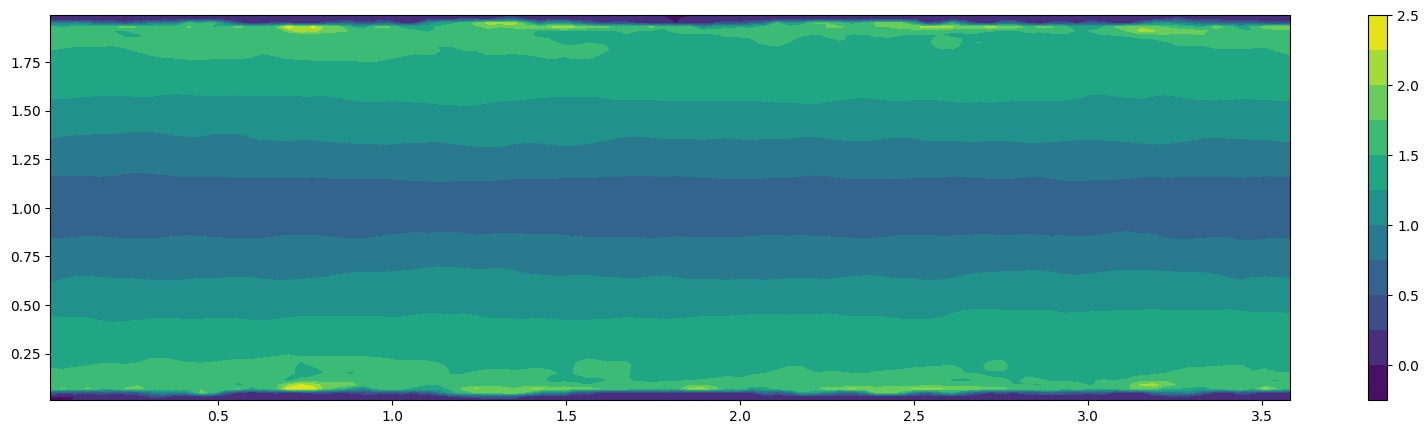

In [152]:
plt.figure(figsize=(20,5))

model_values=produce_sample(3.6,2,0,200)
plt.title("predicted")

In [ ]:
plt.figure(figsize=(20,5))

model_values=produce_sample(3.6,2,100,200)
plt.title("predicted")

In [ ]:
for j in np.linspace(0,2,10):
    coords = torch.tensor([[j,i] for i in np.linspace(0,2,100)], dtype=torch.float32)
    model_out = model(tp.spaces.Points(coords, X*Y)).as_tensor
    plt.plot(np.linspace(0,2,100),np.array(model_out.transpose(0,1)[0].tolist()))
    plt.plot(np.linspace(0,2,100),np.array(model_out.transpose(0,1)[0].tolist())/50)
    #plt.plot([0.4,0.4],[0.1,-0.1])

In [ ]:
coords = torch.tensor([[1,i] for i in np.linspace(0,2,100)], dtype=torch.float32)
model_out = model(tp.spaces.Points(coords, X*Y)).as_tensor
for k in range(2,5):
    plt.plot(np.linspace(0,2,100),np.array(model_out.transpose(0,1)[k].tolist()))
    #plt.plot([0.4,0.4],[0.1,-0.1])

In [ ]:
coords = torch.tensor([[1,i] for i in DF_Data["y"]], dtype=torch.float32)
model_out = model(tp.spaces.Points(coords, X*Y)).as_tensor
for k in range(2,5):
    plt.plot(DF_Data["y"],np.array(model_out.transpose(0,1)[k].tolist()))
    #plt.plot([0.4,0.4],[0.1,-0.1])
plt.plot(DF_Data["y"],DF_Data["urms"],'--')
plt.plot(DF_Data["y"],DF_Data["vrms"],'--')
plt.plot(DF_Data["y"],DF_Data["uv"],'--')

In [ ]:
coords = torch.tensor([[1,i] for i in np.linspace(0,2,100)], dtype=torch.float32)
model_out = model(tp.spaces.Points(coords, X*Y)).as_tensor
for k in range(0,2):
    plt.plot(np.linspace(0,2,100),np.array(model_out.transpose(0,1)[k].tolist()))
    #plt.plot([0.4,0.4],[0.1,-0.1])

In [ ]:
coords = torch.tensor([[1,i] for i in DF_Data["y"]], dtype=torch.float32)
model_out = model(tp.spaces.Points(coords, X*Y)).as_tensor
for k in range(0,1):
    plt.plot(DF_Data["y"],np.array(model_out.transpose(0,1)[k].tolist()))
    #plt.plot([0.4,0.4],[0.1,-0.1])
plt.plot(DF_Data["y"],DF_Data["U"],'--')
#plt.plot(DF_Data["y"],DF_Data["V"],'--')


In [ ]:
coords = torch.tensor([[1,i] for i in DF_Data["y"]], dtype=torch.float32)
model_out = model(tp.spaces.Points(coords, X*Y)).as_tensor
for k in range(0,2):
    plt.plot(DF_Data["y"],np.array(model_out.transpose(0,1)[k].tolist()))
    #plt.plot([0.4,0.4],[0.1,-0.1])

In [ ]:
DF_Data=pd.read_csv("Data/Flow_3d_2289_6.csv")
DF_Data["V"]=DF_Data["V"]*50

In [ ]:
DF_Data["y"].loc[1]

In [ ]:
np.linspace(0,1,10)

In [ ]:
DF_Data_train=pd.read_csv("Data/Flow_3d_2289_6_C20.csv")

In [ ]:
def compare_prediction(DF_Data,x_max,y_max):
    list_x_t=DF_Data_train["x"].values
    list_y_t=DF_Data_train["y"].values
    list_x=DF_Data["x"].values
    list_y=DF_Data["y"].values
    xM=np.reshape(list_x,(-1,226))
    yM=np.reshape(list_y,(-1,226))
    model_value_u=np.zeros(list_x.shape)
    model_value_v=np.zeros(list_x.shape)    
    model_value_urms=np.zeros(list_x.shape)
    model_value_p=np.zeros(list_x.shape)
    for i in range(len(list_x)):
        coords = torch.tensor([[list_x[i],list_y[i]]], dtype=torch.float32)
        model_value_u[i] = 100*torch.abs( (model(tp.spaces.Points(coords, X*Y)).as_tensor[0,0] - torch.tensor(DF_Data["U"].loc[i] ))/torch.tensor(DF_Data["U"].loc[i]))
        model_value_v[i] = 100*torch.abs( model(tp.spaces.Points(coords, X*Y)).as_tensor[0,1] - torch.tensor(DF_Data["V"].loc[i] ))
        model_value_urms[i] = 100*torch.abs( (model(tp.spaces.Points(coords, X*Y)).as_tensor[0,2] - torch.tensor(DF_Data["urms"].loc[i] ))/torch.tensor(DF_Data["urms"].loc[i]))
    model_value_u=np.reshape(model_value_u,(-1,226))
    model_value_v=np.reshape(model_value_v,(-1,226))
    model_value_urms=np.reshape(model_value_urms,(-1,226))
    model_value_urms=np.transpose(model_value_urms)
    model_value_u=np.transpose(model_value_u)
    model_value_v=np.transpose(model_value_v)
    xM=np.transpose(xM)
    yM=np.transpose(yM)
    plt.contourf(xM,yM,np.flip(model_value_u,0),np.linspace(0,50,20),extent=[0, x_max, 0, y_max],origin='lower')    
    plt.colorbar()
    plt.plot(x_corr,dist,"r",linewidth=2) 
    plt.scatter(list_x_t,list_y_t,s=0.8,c="r")
    plt.title("Error, %")

In [ ]:
plt.figure(figsize=(20,10))
compare_prediction(DF_Data,3.6,2)
plt.ylim(top=1)

In [ ]:
DF_Data["x"]

In [ ]:
def plot_test(DF_Data,x_max,y_max):
    list_x=DF_Data["x"].values
    list_y=DF_Data["y"].values
    xM=np.reshape(list_x,(-1,226))
    yM=np.reshape(list_y,(-1,226))
    model_value_u=np.zeros(list_x.shape)
    model_value_v=np.zeros(list_x.shape)    
    model_value_urms=np.zeros(list_x.shape)
    model_value_p=np.zeros(list_x.shape)
    for i in range(len(list_x)):
        model_value_u[i] = DF_Data["U"].iloc[i]
        model_value_v[i] = DF_Data["V"].iloc[i]
        model_value_urms[i] = DF_Data["urms"].iloc[i]
    model_value_u=np.reshape(model_value_u,(-1,226))
    model_value_v=np.reshape(model_value_v,(-1,226))
    model_value_urms=np.reshape(model_value_urms,(-1,226))
    model_value_urms=np.transpose(model_value_urms)
    model_value_u=np.transpose(model_value_u)
    model_value_v=np.transpose(model_value_v)
    xM=np.transpose(xM)
    yM=np.transpose(yM)
    plt.contourf(xM,yM,np.flip(model_value_u,0),10,extent=[0, x_max, 0, y_max],origin='lower')    
    plt.colorbar()
    plt.plot(x_corr,dist)
    plt.title("Truth")
    plt.ylim(top=y_max)
    plt.xlim(left=0,right=x_max)

In [ ]:
def plot_pred(x_max,y_max,other_Constrains,resolution=100):
    list_x=np.linspace(0,x_max,resolution)
    list_y=np.linspace(0,y_max,resolution)
    XM,YM=np.meshgrid(list_x,list_y)
    model_value_x=np.zeros(XM.shape)
    model_value_y=np.zeros(XM.shape)    
    model_value_urms=np.zeros(XM.shape)
    model_value_p=np.zeros(XM.shape)
    for i in range(len(list_x)):
        for j in range(len(list_y)):
            coords = torch.tensor([[list_x[i],list_y[j]]], dtype=torch.float32)
            model_value_x[i,j] = model(tp.spaces.Points(coords, X*Y)).as_tensor[0,0]
            model_value_y[i,j] = model(tp.spaces.Points(coords, X*Y)).as_tensor[0,1]
            model_value_urms[i,j] = model(tp.spaces.Points(coords, X*Y)).as_tensor[0,2]
            model_value_p[i,j] = model(tp.spaces.Points(coords, X*Y)).as_tensor[0,5]
    model_value_urms=np.transpose(model_value_urms)
    model_value_x=np.transpose(model_value_x)
    model_value_y=np.transpose(model_value_y)
    model_value_p=np.transpose(model_value_p)
    plt.contourf(model_value_x,0,levels=10,extent=[0, x_max, 0, y_max],origin='lower')    
    plt.colorbar()
    plt.plot(x_corr,dist)
    plt.ylim(top=y_max)
    plt.xlim(left=0,right=x_max)
    return model_value_x


In [ ]:
plt.figure(figsize=(20,5))

model_values=plot_pred(3.6,2,1,200)
plt.title("predicted")

In [ ]:
plt.figure(figsize=(20,5))

plot_test(DF_Data,3.6,2)
plt.title("Truth")

In [ ]:
for j in np.linspace(0,2,10):
    coords = torch.tensor([[j,i,20] for i in np.linspace(0,2,100)], dtype=torch.float32)
    model_out = model(tp.spaces.Points(coords, X*Y*H)).as_tensor
    plt.plot(np.linspace(0,2,100),np.array(model_out.transpose(0,1)[0].tolist()))
    plt.plot([0.3,0.3],[0.1,-0.1])

In [ ]:
coords = torch.tensor([[5,i] for i in np.linspace(0,2.0,100)], dtype=torch.float32)
model_out = model(tp.spaces.Points(coords, X*Y)).as_tensor
plt.plot(np.array(model_out.transpose(0,1)[0].tolist()))
coords = torch.tensor([[0,i] for i in np.linspace(0,2.0,100)], dtype=torch.float32)
model_out = model(tp.spaces.Points(coords, X*Y)).as_tensor
plt.plot(np.array(model_out.transpose(0,1)[0].tolist()))

In [ ]:
def predic_error(DF_Data,x_max,y_max):
    list_x_t=DF_Data_train["x"].values
    list_y_t=DF_Data_train["y"].values
    list_x=DF_Data["x"].values
    list_y=DF_Data["y"].values
    xM=np.reshape(list_x,(-1,226))
    yM=np.reshape(list_y,(-1,226))
    errorU=0
    errorV=0
    errorurm=0
    erroruv=0
    num=0
    for i in range(len(list_x)):
        position_r=sum(x_corr<list_x[i])-1 
    #position_r=sum(x_corr<x)
        position_l=position_r-1
        x_new=list_x[i]
        height=dist[position_l]+(dist[position_r]-dist[position_l])*(x_new-x_corr[position_l])/(x_corr[position_r]-x_corr[position_l])
        if (list_y[i]> height) & (list_y[i]< 2-height):
            num=num+1
            coords = torch.tensor([[list_x[i],list_y[i]]], dtype=torch.float32)
            errorU = errorU +100*torch.abs( (model(tp.spaces.Points(coords, X*Y)).as_tensor[0,0] - torch.tensor(DF_Data["U"].loc[i] ))/torch.tensor(DF_Data["U"].loc[i]))
            errorV = errorV+ 100*torch.abs( model(tp.spaces.Points(coords, X*Y)).as_tensor[0,1] - torch.tensor(DF_Data["V"].loc[i] ))
            errorurm = errorurm+100*torch.abs( (model(tp.spaces.Points(coords, X*Y)).as_tensor[0,2] - torch.tensor(DF_Data["urms"].loc[i] ))/torch.tensor(DF_Data["urms"].loc[i]))
            erroruv = erroruv+100*torch.abs( (model(tp.spaces.Points(coords, X*Y)).as_tensor[0,4] - torch.tensor(DF_Data["uv"].loc[i] ))/torch.tensor(DF_Data["uv"].loc[i]))
    errorU=errorU/num
    errorV=errorV/num
    errorurm=errorurm/num
    erroruv=erroruv/num
    return {"Err_U":errorU, "Err_V":errorV,"Err_urms":errorurm,"Err_uv":erroruv}

In [ ]:
Errors=predic_error(DF_Data,3.6,2)


In [ ]:
Errors